# **4. Modeling**

In [51]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, \
    RidgeClassifier, Lasso
from sklearn.metrics import classification_report,ConfusionMatrixDisplay,confusion_matrix,\
      roc_auc_score, roc_curve,auc,precision_score, recall_score, f1_score, root_mean_squared_error

In [52]:
# Load prepared data
X_train = pd.read_csv('../Data/model_data/x_train_ready.csv')
X_test = pd.read_csv('../Data/model_data/x_test_ready.csv')
y_train = pd.read_csv('../Data/model_data/y_train_ready.csv').values.ravel()
y_test = pd.read_csv('../Data/model_data/y_test_ready.csv').values.ravel()

# Data Preprocessing
- ##### Drop 'Minutes' columns due to their perfect correlation with 'charges' columns (Multicollinearity Problem) as discovered during the EDA process.

In [53]:
X_train.head()

,account length,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,international plan_yes,voice mail plan_yes,area code_415,area code_510,state_encoded
0,0.125737,1.606822,0.743376,0.225611,0.743639,0.426270,0.445403,0.426916,-0.843159,-0.195702,-0.842280,1.018565,1.436500,1.021815,-1.200212,0.0,1.0,1.0,0.0,0.108696
1,-0.175309,-0.588791,-0.401294,0.225611,-0.401678,-0.904961,0.045354,-0.903861,-0.218499,-0.808555,-0.219411,-0.800731,0.203496,-0.801460,1.875007,0.0,0.0,0.0,0.0,0.186047
2,-0.752313,1.021325,-0.704945,0.325566,-0.704787,-0.746481,0.245378,-0.745379,0.390145,-0.042489,0.390111,-1.656870,-0.618506,-1.660249,0.337397,0.0,1.0,0.0,1.0,0.048780
3,0.727828,-0.588791,-2.048368,-0.723960,-2.048208,-0.146239,0.495409,-0.146413,-0.580882,2.000353,-0.579785,0.055409,-0.207505,0.057329,-1.200212,0.0,0.0,0.0,0.0,0.135135
4,-0.350919,-0.588791,0.800425,0.425520,0.799931,-1.449735,-0.704736,-1.449223,1.777611,-0.859626,1.778219,1.517980,-0.207505,1.523876,1.106202,0.0,0.0,0.0,1.0,0.142857


In [54]:
# List of columns to drop (all 'minutes' columns)
cols_to_drop = [col for col in X_train.columns if 'minutes' in col]

# Drop from both Train and Test
X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)

Four redundant columns were dropped:
- 'total day minutes', 
- 'total eve minutes', 
- 'total night minutes', 
- 'total intl minutes'

There are 16 remaining features which will be used to train the models.

## Class Imbalance

In [55]:
# Check for class imbalance
count_y_values =pd.DataFrame(y_train.copy())
count_y_values.value_counts()

0
0    2280
1     386
Name: count, dtype: int64

#####  Majority of customers stayed while a few left. 
##### Class imbalace will be solved using different methods and the model with best solution will be recommended.

## Fitting the baseline Model:

In [56]:
# Fit baseline model
baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## Model Evaluation:

In [57]:
# AUC
y_base_scores = baseline_model.fit(X_train, y_train).decision_function(X_test)
b_fpr, b_tpr, b_thresholds = roc_curve(y_test, y_base_scores)
auc_base = roc_auc_score(y_test,y_base_scores)
auc_base

0.8171278712244529

In [58]:
# Make predictions
y_base_probs = baseline_model.predict_proba(X_test)[:, 1]
y_pred_base = (y_base_probs >= 0.5).astype(int)

In [59]:
# Classification report
print(classification_report(y_test, y_pred_base))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       570
           1       0.54      0.23      0.32        97

    accuracy                           0.86       667
   macro avg       0.71      0.60      0.62       667
weighted avg       0.83      0.86      0.83       667



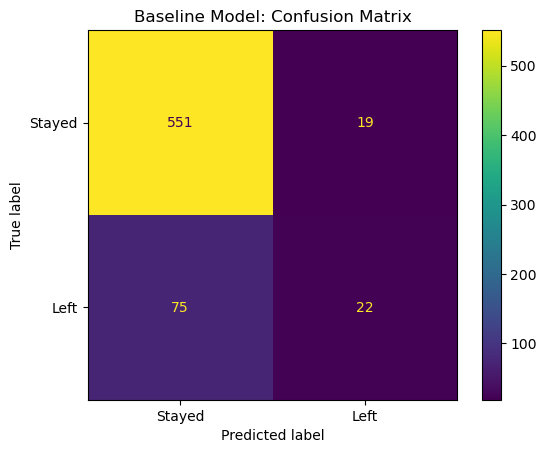

In [60]:
# Confusion Matrix
b_cm = confusion_matrix(y_test,y_pred_base, labels = [0,1])
disp = ConfusionMatrixDisplay(confusion_matrix = b_cm,display_labels=['Stayed', 'Left'])
disp.plot() 
plt.title('Baseline Model: Confusion Matrix')
plt.grid(False) 
plt.show()

# Fit Refined Model

In [61]:
# handle class imbalance using class weights
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

# Fit the model
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


## Model Evaluation

In [62]:
# AUC
y_scores = model.fit(X_train, y_train).decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
auc = roc_auc_score(y_test,y_scores)
auc

0.8161331162958944

In [63]:
# Get Predicted Probabilities
# Column 1 represents the probability of Churn
y_probs = model.predict_proba(X_test)[:, 1]

# 4. Apply a custom threshold to prioritize Recall
threshold = 0.4
y_pred = (y_probs >= threshold).astype(int)

In [64]:
# Classification report
print(f"--- Refined Model (Threshold: {threshold}) ---")
print(classification_report(y_test, y_pred))

--- Refined Model (Threshold: 0.4) ---
              precision    recall  f1-score   support

           0       0.96      0.65      0.78       570
           1       0.29      0.82      0.43        97

    accuracy                           0.68       667
   macro avg       0.62      0.74      0.60       667
weighted avg       0.86      0.68      0.73       667



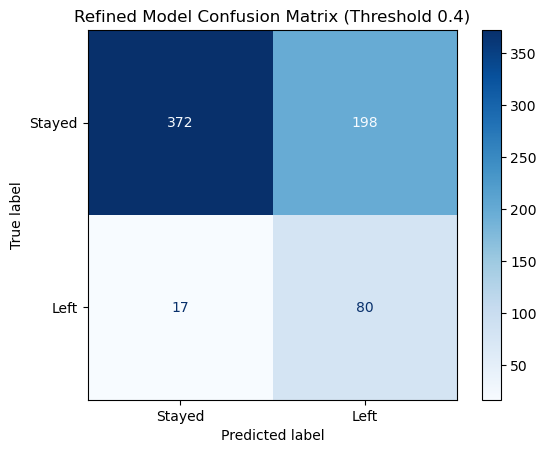

In [65]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title(f'Refined Model Confusion Matrix (Threshold {threshold})')
plt.show()

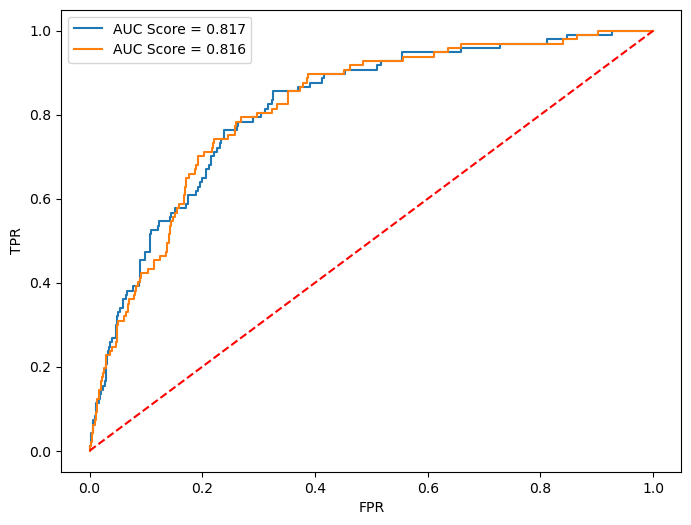

In [66]:
# ROC curve 
plt.figure(figsize=(8,6))
plt.plot(b_fpr,b_tpr,label = f"AUC Score = {auc_base:.3f}")
plt.plot(fpr,tpr,label = f"AUC Score = {auc:.3f}")

plt.plot([0,1],[0,1], linestyle = '--', color='red')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

# **5. Evaluation**
## Comparison of the two Models

##### **Comparison by Metrics**

In [67]:
# Calculate metrics for Baseline
p_base = precision_score(y_test, y_pred_base)
r_base = recall_score(y_test, y_pred_base)
f1_base = f1_score(y_test, y_pred_base)

# Calculate metrics for Refined
p_ref = precision_score(y_test, y_pred)
r_ref = recall_score(y_test, y_pred)
f1_ref = f1_score(y_test, y_pred)

# Print the Metrics
print(f"base precision: {p_base:.2f}")
print(f"base recall: {r_base:.2f}")
print(f"base f1-score: {f1_base:.2f}")
print(f"Refined precision: {p_ref:.2f}")
print(f"Refined recall: {r_ref:.2f}")
print(f"Refined f1-score: {f1_ref:.2f}")


base precision: 0.54
base recall: 0.23
base f1-score: 0.32
Refined precision: 0.29
Refined recall: 0.82
Refined f1-score: 0.43


### Model Performance Comparison

| Metric | Baseline Model | Refined Model |
| :--- | :---: | :---: |
| **Accuracy** | 0.86 | 0.68 |
| **Precision** | 0.54 | 0.29 |
| **Recall** | 0.23 | **0.82** |
| **AUC Score** | 0.82 | 0.82 |
| **False Negatives** | 75 | **17** |
| **False Positives** | 19 | 198 |
| **F1-Score** | 0.32 | 0.43 |

- AUC score difference is negligible. Predictive power remains intact for the refined model.
- Refined model has a lower RMSE by margin mmaking it the suitable one for prediction.

##### **Comparison by Confusion Matrix**

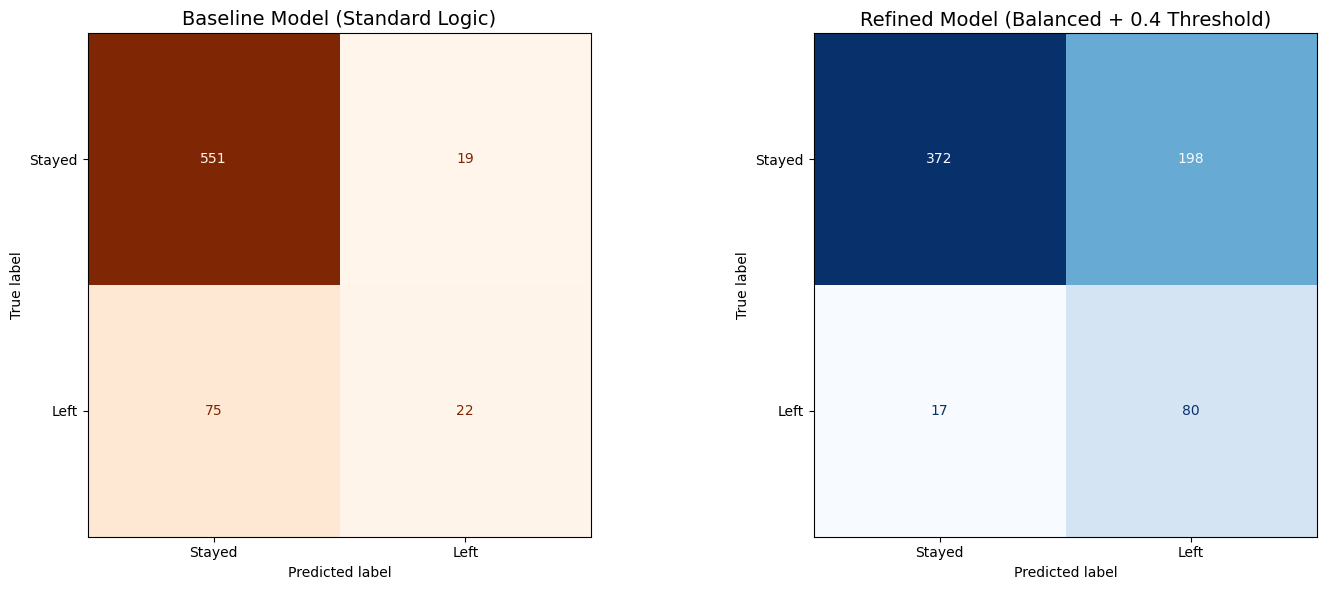

In [68]:
# Comparison of the two models

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Baseline Model
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_base, 
    display_labels=['Stayed', 'Left'], 
    cmap='Oranges', ax=ax1, colorbar=False
)
ax1.set_title('Baseline Model (Standard Logic)', fontsize=14)

# Refined Model
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, 
    display_labels=['Stayed', 'Left'], 
    cmap='Blues', ax=ax2, colorbar=False
)
ax2.set_title(f'Refined Model (Balanced + {threshold} Threshold)', fontsize=14)

plt.tight_layout()
plt.show()

# **Rationale**
- **Prioritize Recall** - Recall is the decisive metric between the two models. 
- **Objective** - Minimize False Negatives (Catch almost every customer who was going to leave).
- **Expense** - Higher False Positives (Customers who were predicted to leave buy they stayed)

**Else**

- **Prioritize Precision** - Not recommended
- **Objective** - Minimize False Positives (If model predicts a customer will leave, they will difinately leave).
- **Expense** - Higher False Negatives (Customers who were predicted to stay but they left)

**Why prioritize Recall?** 
- I would rather 'annoy' 198 customers that are predicted to leave but they stay, while 'saving' 80 others that were leaving, than 'annoying' only 19 and losing 75 customers that are predicted to stay yet they are leaving.

# **Recommendations**


#### **What are the Churn Driving features according to the Refined Model?** 

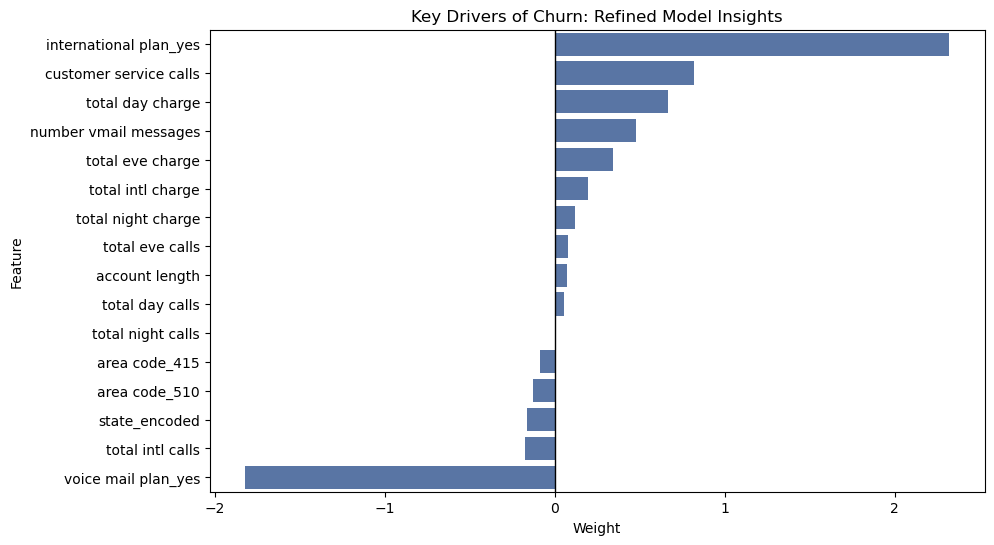

In [69]:
# Show Key Contributors of Churn

importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight': model.coef_[0]
}).sort_values(by='Weight', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Weight', y='Feature', color='#4C72B0')
plt.title('Key Drivers of Churn: Refined Model Insights')
plt.axvline(0, color='black', lw=1)
plt.show()

#### **Insights and Recommendations**

#### Feature 1: International Plan
- Having an International Plan is the strongest preditor of Churn. EDA showed that customers with international plans perceive the charges for international calls to be high.


- **Recommendation** - *Reach out to international plan users with a more convincing pricing tier*

#### Feature 2: Customer Service Calls
- Every additional call to customer service significantly increases the likelihood of leaving. EDA revealed that the count of customers who leave exceed the count of customers who stay after four customer service calls.


- **Recommendation** - *If a customer calls more than 3 times in a month, they should be automatically flagged for a follow-up from a senior retention specialist.*

#### Feature 3: Total Day Charge
- Just like Customer Service Calls, every additional dollar to the daily charge significantly increases the likelihood of leaving. EDA revealed that churn rate spikes after ~48$. Customers within this daily spend are actively looking for cheaper alternatives.


- **Recommendation** - *Introduce discounts for customers spending over $40 to keep their daily charge below $45.*

#### Feature 4: Voice Mail Plan
- Having a voice mail plan is the strongest negative coefficient (it pushes people to stay).


- **Recommendation** - *Voicemail Onboarding! Get new customers to set up their voicemail early to improve long term retention.*

##### *Review EDA Findings and Insights in the ['churn_eda'](https://github.com/clivekinyanjui/Telecom-Customer-Retention/blob/main/Notebooks/churn_eda.ipynb) notebook.*

# **Conclusion**

- *The Refined Model prioritizes recall(82%) and is able to identify high-risk customers with an international plan and frequent customer service callers early. This allows the stakeholders to move from losing 75 customers silently to securing 80 high-risk customers through targeted interventions.*

# **Limitations**
- **Linear Assumptions** - Logistic Regression assumes linear relationships between features. Complex non-linear interactions might be missed.

- **Precision Trade-off** - Low Precision(29%) means loyal customers are flagged. 

- **Missing competitors' data** - A customer may leave because a competitor offered a better price deal, which the model cannot 'see'.

- **Lack of Seasonality** - Data represents only a specific point in time. The model cannot answer questions like, 'do customers churn more in May?'